# **사망 진단 예측 모델 최종 LightGBM**

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np

# 드라이브 마운트
drive.mount('/content/drive')

# 1. 파일이 저장된 정확한 경로 (본인의 경로에 맞게 수정하세요)
base_path = '/content/drive/MyDrive/ColabNotebooks/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


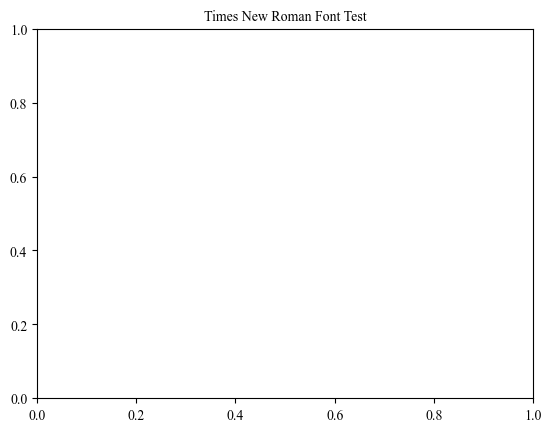

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 파일의 경로를 직접 입력
font_path = '/content/drive/MyDrive/TimesNewerRoman/Times New Roman.ttf'

# 폰트를 Matplotlib 폰트 관리자에 추가
fm.fontManager.addfont(font_path)

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()

# 테스트
plt.title("Times New Roman Font Test", fontproperties=font_prop)
plt.show()

✅ 데이터 준비 완료 (사용한 변수 개수: 45개)

[모델 학습 시작]
✅ Random Forest       : AUC=0.9057, PR-AUC=0.3639
✅ XGBoost             : AUC=0.9214, PR-AUC=0.4153
✅ LightGBM            : AUC=0.9235, PR-AUC=0.4298
✅ Logistic Regression : AUC=0.9182, PR-AUC=0.3866


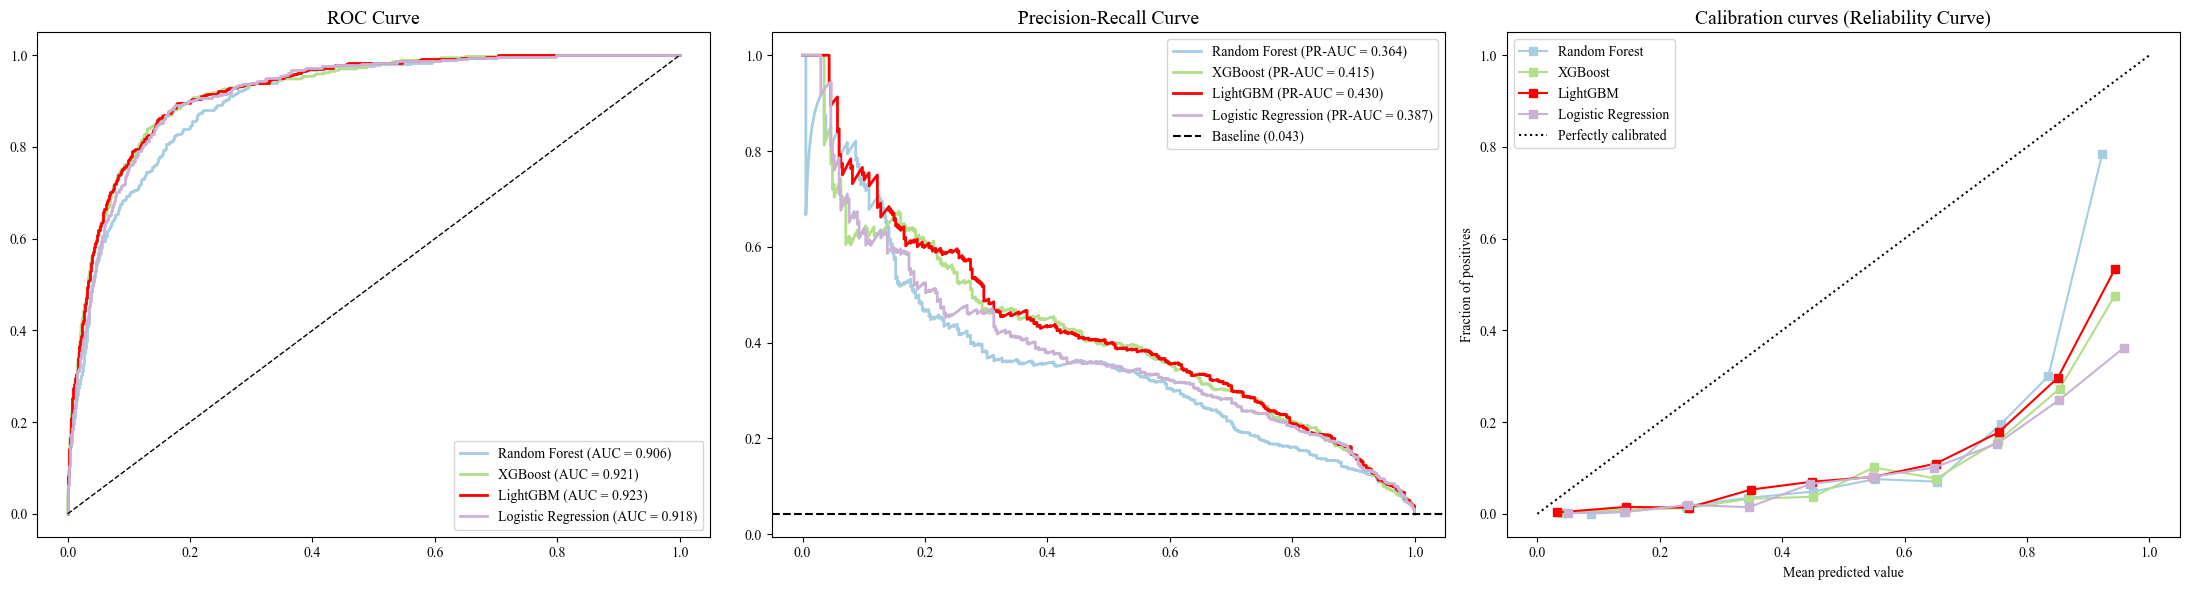

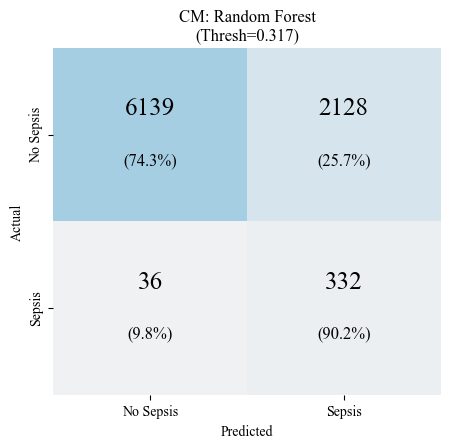

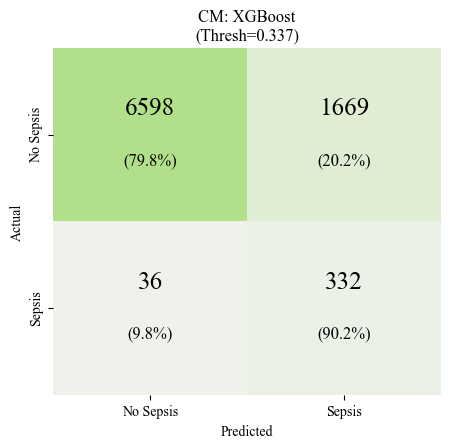

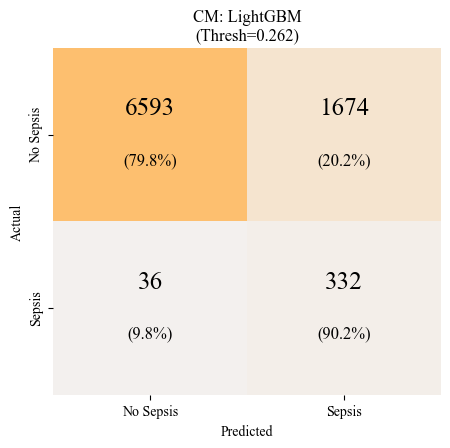

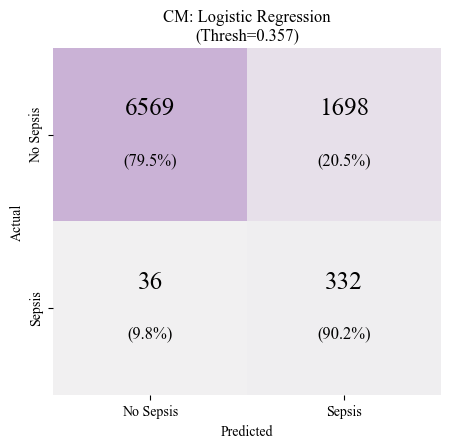


[7] SHAP 해석 (LightGBM 기준)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


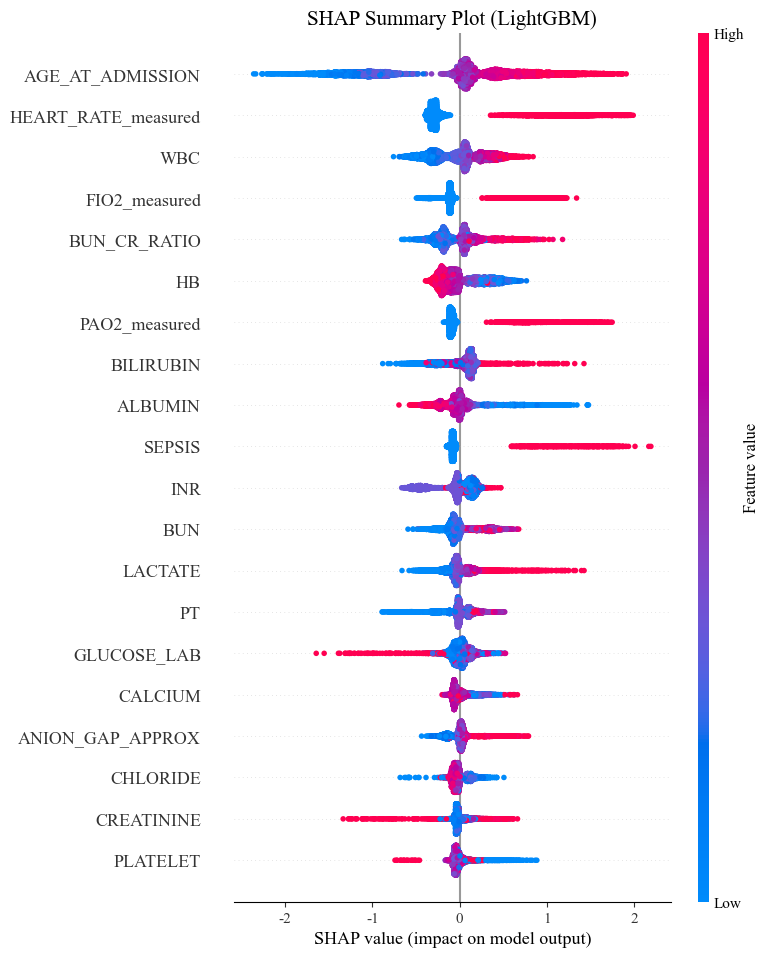


🎯 분석 요약
  - Random Forest: AUC=0.9057, PR-AUC=0.3639
  - XGBoost: AUC=0.9214, PR-AUC=0.4153
  - LightGBM: AUC=0.9235, PR-AUC=0.4298
  - Logistic Regression: AUC=0.9182, PR-AUC=0.3866
2. 주요 사망 위험 요인(OR 상위): SBP_measured (OR: 2.85)

🏆 Best Model
  - Model: LightGBM
  - AUC: 0.9235
  - PR-AUC: 0.4298


<Figure size 640x480 with 0 Axes>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (  roc_curve, roc_auc_score, confusion_matrix,
    classification_report, accuracy_score, precision_recall_curve,
    auc, f1_score, recall_score, precision_score, average_precision_score )

# 0. 설정 및 경로
base_path = '/content/drive/MyDrive/ColabNotebooks/'
figures_path = f'{base_path}figures'
color_list = ["#A6CEE3", "#B2DF8A", "#FDBF6F", "#CAB2D6", "#FB9A99"]
model_colors = {
    'Random Forest': color_list[0],
    'XGBoost': color_list[1],
    'LightGBM': color_list[2], # LightGBM의 혼동 행렬 색상을 원래 색상으로 설정
    'Logistic Regression': color_list[3]
}
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터 로드
train_df = pd.read_csv(f'{base_path}cohort_csv/train_final.csv')
test_df = pd.read_csv(f'{base_path}cohort_csv/test_final.csv')

# 2. 변수 분류 및 전처리
target = 'HOSPITAL_EXPIRE_FLAG'
exclude_vars = [target, 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME']
feature_cols = [c for c in train_df.columns if c not in exclude_vars]

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

# 로지스틱 회귀를 위한 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print(f"✅ 데이터 준비 완료 (사용한 변수 개수: {len(feature_cols)}개)")

# 3. 모델 정의 및 학습
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=500, learning_rate=0.03, importance_type='gain', class_weight='balanced', random_state=42, verbose=-1, max_depth=5, num_leaves=15, min_child_samples=20, lambda_l1=0.1),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
}

results = {}

print("\n[모델 학습 시작]")
for name, model in models_dict.items():
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train
    cur_X_test = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(cur_X_train, y_train)
    y_prob = model.predict_proba(cur_X_test)[:, 1]

    # Recall 0.9 기반 최적 임계값 찾기 (for the current model)
    recalls = [recall_score(y_test, (y_prob >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
    valid_idx = np.where(np.array(recalls) >= 0.90)[0]
    best_threshold = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5 # Using 0.5 as fallback

    # 최적 임계값으로 예측 (for the current model)
    y_pred_optimal = (y_prob >= best_threshold).astype(int)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    results[name] = {
        'prob': y_prob,
        'pred': y_pred_optimal,
        'threshold': best_threshold,
        'auc': roc_auc_score(y_test, y_prob),
        'pr_auc': auc(recall, precision),
        'model': model
    }
    print(f"✅ {name:20}: AUC={results[name]['auc']:.4f}, PR-AUC={results[name]['pr_auc']:.4f}")

# 4-1. 시각화 (ROC, PRC & Calibration Curve)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for name, res in results.items():
    plot_color = 'red' if name == 'LightGBM' else model_colors[name] # LightGBM ROC/PRC는 빨간색으로 표시

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=plot_color, lw=2)

    # PRC Curve
    precision, recall, _ = precision_recall_curve(y_test, res['prob'])
    axes[1].plot(recall, precision, label=f"{name} (PR-AUC = {res['pr_auc']:.3f})", color=plot_color, lw=2)

    # Calibration Curve
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, res['prob'], n_bins=10)
    axes[2].plot(mean_predicted_value, fraction_of_positives, "s-", label=name, color=plot_color)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve', fontsize=14)
axes[0].legend()

no_skill = len(y_test[y_test==1]) / len(y_test)
axes[1].axhline(y=no_skill, color='k', linestyle='--', label=f'Baseline ({no_skill:.3f})')
axes[1].set_title('Precision-Recall Curve', fontsize=14)
axes[1].legend()

axes[2].plot([0, 1], [0, 1], 'k:', label='Perfectly calibrated')
axes[2].set_xlabel('Mean predicted value')
axes[2].set_ylabel('Fraction of positives')
axes[2].set_title('Calibration curves (Reliability Curve)', fontsize=14)
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{figures_path}/roc_prc_calibration_curves.png', dpi=300, bbox_inches='tight')
plt.show()

for i, (name, res) in enumerate(results.items()):
    fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
    cm = confusion_matrix(y_test, res['pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Calculate percentages

    # model_colors[name]은 이제 LightGBM에 대해 color_list[2] (주황색)을 반환합니다.
    cmap = sns.light_palette(model_colors[name], as_cmap=True)
    sns.heatmap(cm, annot=False, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['No Sepsis','Sepsis'], yticklabels=['No Sepsis','Sepsis'])

    # Manually add annotations with different font sizes and positions
    for (j, k), count in np.ndenumerate(cm):
        percentage = cm_norm[j, k]
        ax.text(k + 0.5, j + 0.35, f"{count}",
                ha='center', va='center', fontsize=18, color='black', fontweight='bold') # Large, bold count
        ax.text(k + 0.5, j + 0.65, f"({percentage:.1%})",
                ha='center', va='center', fontsize=12, color='black') # Smaller percentage

    ax.set_title(f"CM: {name}\n(Thresh={res['threshold']:.3f})", fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Save each confusion matrix plot
    plt.savefig(f'{figures_path}/confusion_matrix_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# 7. SHAP 해석 (LightGBM 기준)
print("\n" + "="*80)
print("[7] SHAP 해석 (LightGBM 기준)")
explainer = shap.TreeExplainer(results['LightGBM']['model'])
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list): shap_values = shap_values[1]

plt.figure(figsize=(10, 6))
# 별도의 이름 매핑 없이 원본 X_test 사용 (컬럼명이 자동으로 들어감)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (LightGBM)", fontsize=15)
plt.show()

# Save SHAP plot before showing
plt.tight_layout()
plt.savefig(f'{figures_path}/shap_summary_plot_LightGBM.png', dpi=300, bbox_inches='tight')

# 최종 요약
print("\n" + "="*80)
print("🎯 분석 요약")
for name, res in results.items():
    print(f"  - {name}: AUC={res['auc']:.4f}, PR-AUC={res['pr_auc']:.4f}")

# 로지스틱 회귀 Odds Ratio 분석 결과는 더 이상 필요 없으므로 주석 처리하거나 제거 (여기서는 제거)
or_df = pd.DataFrame({
    'Feature': feature_cols,
    'OR': np.exp(results['Logistic Regression']['model'].coef_[0]),
    'Coef': results['Logistic Regression']['model'].coef_[0]
}).sort_values(by='OR', ascending=False)
print(f"2. 주요 사망 위험 요인(OR 상위): {or_df.iloc[0]['Feature']} (OR: {or_df.iloc[0]['OR']:.2f})")

# =============================================================================
# 7. 최고 성능 모델 선택
# =============================================================================

# PR-AUC 기준 최고 모델
best_model = max(results.items(), key=lambda x: x[1]['pr_auc'])

print("\n🏆 Best Model")
print(f"  - Model: {best_model[0]}")
print(f"  - AUC: {best_model[1]['auc']:.4f}")
print(f"  - PR-AUC: {best_model[1]['pr_auc']:.4f}")

In [4]:
print("\n" + "="*80)
print("[LightGBM 모델: Recall 0.9 기반 최적 임계값 적용]")

y_test_proba_lgbm = results['LightGBM']['prob']

# Recall 0.9 기반 최적 임계값 찾기
recalls_lgbm = [recall_score(y_test, (y_test_proba_lgbm >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx_lgbm = np.where(np.array(recalls_lgbm) >= 0.90)[0]
best_rec_t_lgbm = np.linspace(0.01, 0.99, 1000)[valid_idx_lgbm[-1]] if len(valid_idx_lgbm) > 0 else 0.5

# 최적 임계값으로 예측
y_pred_lgbm_rec90 = (y_test_proba_lgbm >= best_rec_t_lgbm).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lgbm_rec90).ravel()

print(f"  - 최적 임계값 (Recall 0.9): {best_rec_t_lgbm:.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_lgbm_rec90):.4f}")
print(f"  - Recall:    {recall_score(y_test, y_pred_lgbm_rec90):.4f}")
print(f"  - F1-Score:  {f1_score(y_test, y_pred_lgbm_rec90):.4f}")
print(f"  - Specificity: {tn/(tn+fp):.4f}")
print(f"\n" + "="*80)


[LightGBM 모델: Recall 0.9 기반 최적 임계값 적용]
  - 최적 임계값 (Recall 0.9): 0.2621
  - Precision: 0.1655
  - Recall:    0.9022
  - F1-Score:  0.2797
  - Specificity: 0.7975



### 모델별 훈련 데이터셋 성능 평가 (과적합 확인)

In [5]:
print("\n" + "="*80)
print("[8] 훈련 데이터셋 성능 평가 (과적합 확인)")

train_results = {}

for name, res in results.items():
    model = res['model']

    # 로지스틱 회귀는 스케일링된 데이터를 사용해야 함
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train

    y_prob_train = model.predict_proba(cur_X_train)[:, 1]

    precision_train, recall_train, _ = precision_recall_curve(y_train, y_prob_train)

    train_results[name] = {
        'auc_train': roc_auc_score(y_train, y_prob_train),
        'pr_auc_train': auc(recall_train, precision_train)
    }
    print(f"✅ {name:20}: Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}")

print("\n" + "="*80)
print("🎯 최종 비교: 훈련 vs. 테스트 성능")
for name, res in results.items():
    print(f"  - {name}:\n    Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}\n    Test AUC={res['auc']:.4f}, Test PR-AUC={res['pr_auc']:.4f}")
    if train_results[name]['auc_train'] - res['auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train AUC와 Test AUC 차이: {:.2f})".format(train_results[name]['auc_train'] - res['auc']))
    if train_results[name]['pr_auc_train'] - res['pr_auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: {:.2f})".format(train_results[name]['pr_auc_train'] - res['pr_auc']))



[8] 훈련 데이터셋 성능 평가 (과적합 확인)
✅ Random Forest       : Train AUC=0.9205, Train PR-AUC=0.4542
✅ XGBoost             : Train AUC=0.9526, Train PR-AUC=0.5364
✅ LightGBM            : Train AUC=0.9753, Train PR-AUC=0.6718
✅ Logistic Regression : Train AUC=0.9197, Train PR-AUC=0.3844

🎯 최종 비교: 훈련 vs. 테스트 성능
  - Random Forest:
    Train AUC=0.9205, Train PR-AUC=0.4542
    Test AUC=0.9057, Test PR-AUC=0.3639
  - XGBoost:
    Train AUC=0.9526, Train PR-AUC=0.5364
    Test AUC=0.9214, Test PR-AUC=0.4153
    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: 0.12)
  - LightGBM:
    Train AUC=0.9753, Train PR-AUC=0.6718
    Test AUC=0.9235, Test PR-AUC=0.4298
    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: 0.24)
  - Logistic Regression:
    Train AUC=0.9197, Train PR-AUC=0.3844
    Test AUC=0.9182, Test PR-AUC=0.3866


위 결과를 통해 각 모델의 훈련 성능과 테스트 성능을 비교하여 과적합 여부를 판단할 수 있습니다. 훈련 성능이 테스트 성능보다 훨씬 높게 나온다면 해당 모델은 과적합되었을 가능성이 있습니다. 모델의 복잡도를 줄이거나 더 많은 데이터를 확보하는 등의 방법으로 과적합을 해소할 수 있습니다.

## 과적합 해결 - 파라미터 튜닝

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    classification_report, accuracy_score, precision_recall_curve,
    auc, f1_score, recall_score, precision_score, average_precision_score )

# 0. 설정 및 경로
base_path = '/content/drive/MyDrive/ColabNotebooks/'
color_list = ["#A6CEE3", "#B2DF8A", "#FDBF6F", "#CAB2D6", "#FB9A99"]
model_colors = {
    'Random Forest': color_list[0],
    'XGBoost': color_list[1],
    'LightGBM': color_list[2],
    'Logistic Regression': color_list[3]
}
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터 로드
train_df = pd.read_csv(f'{base_path}cohort_csv/train_final.csv')
test_df = pd.read_csv(f'{base_path}cohort_csv/test_final.csv')

# 2. 변수 분류 및 전처리
target = 'HOSPITAL_EXPIRE_FLAG'
exclude_vars = [target, 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME']
feature_cols = [c for c in train_df.columns if c not in exclude_vars]

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

# 로지스틱 회귀를 위한 스케일링
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print(f"✅ 데이터 준비 완료 (사용한 변수 개수: {len(feature_cols)}개)")

# 3. 모델 정의 및 학습
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), eval_metric='logloss', random_state=42, min_child_weight=20, reg_lambda=5.0, reg_alpha=5.0, subsample=0.8, colsample_bytree=0.8),
    'LightGBM': LGBMClassifier(n_estimators=500, learning_rate=0.03, importance_type='gain', class_weight='balanced', random_state=42, verbose=-1, max_depth=3, num_leaves=8, min_child_samples=100, lambda_l1=1.0, lambda_l2=1.0, subsample=0.8, colsample_bytree=0.8),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
}

results = {}

print("\n[모델 학습 시작]")
for name, model in models_dict.items():
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train
    cur_X_test = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(cur_X_train, y_train)
    y_prob = model.predict_proba(cur_X_test)[:, 1]

    # Youden's Index 기반 최적 임계값
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    best_threshold = thresholds[np.argmax(tpr - fpr)]
    y_pred_optimal = (y_prob >= best_threshold).astype(int)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    results[name] = {
        'prob': y_prob,
        'pred': y_pred_optimal,
        'threshold': best_threshold,
        'auc': roc_auc_score(y_test, y_prob),
        'pr_auc': auc(recall, precision),
        'model': model
    }
    # 각 모델의 학습 완료 메시지는 제거하고 최종 '모든 모델 학습 완료!' 메시지만 남깁니다.

print("\n✅ 모든 모델 학습 완료!")

✅ 데이터 준비 완료 (사용한 변수 개수: 45개)

[모델 학습 시작]

✅ 모든 모델 학습 완료!


## 과적합 해결 확인

In [9]:
print("\n" + "="*80)
print("[8] 훈련 데이터셋 성능 평가 (과적합 확인)")

train_results = {}

for name, res in results.items():
    model = res['model']

    # 로지스틱 회귀는 스케일링된 데이터를 사용해야 함
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train

    y_prob_train = model.predict_proba(cur_X_train)[:, 1]

    precision_train, recall_train, _ = precision_recall_curve(y_train, y_prob_train)

    train_results[name] = {
        'auc_train': roc_auc_score(y_train, y_prob_train),
        'pr_auc_train': auc(recall_train, precision_train)
    }
    print(f"✅ {name:20}: Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}")

print("\n" + "="*80)
print("🎯 최종 비교: 훈련 vs. 테스트 성능")
for name, res in results.items():
    print(f"  - {name}:\n    Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}\n    Test AUC={res['auc']:.4f}, Test PR-AUC={res['pr_auc']:.4f}")
    if train_results[name]['auc_train'] - res['auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train AUC와 Test AUC 차이: {:.2f})".format(train_results[name]['auc_train'] - res['auc']))
    if train_results[name]['pr_auc_train'] - res['pr_auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: {:.2f})".format(train_results[name]['pr_auc_train'] - res['pr_auc']))


[8] 훈련 데이터셋 성능 평가 (과적합 확인)


KeyboardInterrupt: 

## 최종 모델 저장

In [7]:
import joblib
import os

print("\n" + "="*80)
print("[최종 LightGBM 모델 저장]")

# LightGBM 모델 가져오기
final_lgbm_model = results['LightGBM']['model']

# 저장할 경로 설정
model_save_path = os.path.join(base_path, 'LightGBM_final_model.joblib')

# 모델 저장
joblib.dump(final_lgbm_model, model_save_path)

print(f"✅ LightGBM 모델이 다음 경로에 저장되었습니다: {model_save_path}")
print("\n" + "="*80)


[최종 LightGBM 모델 저장]
✅ LightGBM 모델이 다음 경로에 저장되었습니다: /content/drive/MyDrive/ColabNotebooks/LightGBM_final_model.joblib



## 최종 모델 성능확인

In [8]:
import joblib
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, recall_score, precision_score, f1_score, confusion_matrix

print("\n" + "="*80)
print("[저장된 LightGBM 모델 성능 평가]")

# 저장된 LightGBM 모델 로드
try:
    loaded_lgbm_model = joblib.load(model_save_path)
    print(f"✅ LightGBM 모델이 {model_save_path}에서 성공적으로 로드되었습니다.")
except FileNotFoundError:
    print(f"❌ 오류: 모델 파일이 다음 경로에 없습니다: {model_save_path}")
    print("    '최종 LightGBM 모델 저장' 셀을 먼저 실행하여 모델을 저장해 주세요.")
    exit()

# 로드된 모델로 예측 확률 계산
y_prob_loaded_lgbm = loaded_lgbm_model.predict_proba(X_test)[:, 1]

# Recall 0.9 기반 최적 임계값 찾기 (이전 코드에서 사용된 방식)
recalls_lgbm = [recall_score(y_test, (y_prob_loaded_lgbm >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx_lgbm = np.where(np.array(recalls_lgbm) >= 0.90)[0]
best_rec_t_lgbm = np.linspace(0.01, 0.99, 1000)[valid_idx_lgbm[-1]] if len(valid_idx_lgbm) > 0 else 0.5

# 최적 임계값으로 예측
y_pred_lgbm_rec90 = (y_prob_loaded_lgbm >= best_rec_t_lgbm).astype(int)

# 성능 지표 계산
conf_matrix = confusion_matrix(y_test, y_pred_lgbm_rec90)
tn, fp, fn, tp = conf_matrix.ravel()

current_auc = roc_auc_score(y_test, y_prob_loaded_lgbm)
precision, recall, _ = precision_recall_curve(y_test, y_prob_loaded_lgbm)
current_pr_auc = auc(recall, precision)
current_precision = precision_score(y_test, y_pred_lgbm_rec90)
current_recall = recall_score(y_test, y_pred_lgbm_rec90)
current_f1 = f1_score(y_test, y_pred_lgbm_rec90)
current_specificity = tn / (tn + fp)

print(f"  - 모델명: LightGBM (저장된 모델)")
print(f"  - AUC: {round(current_auc, 3):.4f}")
print(f"  - PR-AUC: {round(current_pr_auc, 3):.4f}")
print(f"  - 최적 임계값 (Recall 0.9 기반): {best_rec_t_lgbm:.4f}")
print(f"  - Precision: {current_precision:.4f}")
print(f"  - Recall:    {current_recall:.4f}")
print(f"  - F1-Score:  {current_f1:.4f}")
print(f"  - Specificity: {current_specificity:.4f}")
print("\n" + "="*80)


[저장된 LightGBM 모델 성능 평가]
✅ LightGBM 모델이 /content/drive/MyDrive/ColabNotebooks/LightGBM_final_model.joblib에서 성공적으로 로드되었습니다.
  - 모델명: LightGBM (저장된 모델)
  - AUC: 0.9240
  - PR-AUC: 0.4180
  - 최적 임계값 (Recall 0.9 기반): 0.3553
  - Precision: 0.1700
  - Recall:    0.9022
  - F1-Score:  0.2861
  - Specificity: 0.8039

